# 🌾 Crop Production Statistics — India
## Complete Exploratory Data Analysis (EDA)
> **Dataset**: APY.csv &nbsp;|&nbsp; Indian agricultural crop production (1997–2020)  
> **Columns**: State, District, Crop, Crop_Year, Season, Area, Production, Yield  
> **Goal**: Understand data quality, distributions, trends, and prepare features for ML.


---
## 1. Setup & Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Styling ──────────────────────────────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': '#0f1117',
    'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#444',
    'axes.labelcolor': '#e0e0e0',
    'axes.titlecolor': '#ffffff',
    'xtick.color': '#aaaaaa',
    'ytick.color': '#aaaaaa',
    'text.color': '#e0e0e0',
    'grid.color': '#2e2e2e',
    'legend.facecolor': '#1a1d27',
    'legend.edgecolor': '#444',
    'font.family': 'DejaVu Sans',
    'font.size': 10,
})

ACCENT  = '#00d4aa'
PALETTE = ['#00d4aa','#ff6b6b','#ffd166','#06d6a0','#118ab2','#ef476f','#073b4c','#8338ec']
print('Libraries loaded ✓')


Libraries loaded ✓


---
## 2. Load Dataset


In [2]:
df = pd.read_csv('APY.csv')
df.columns = df.columns.str.strip()   # remove accidental whitespace in headers

# Rename to consistent internal names
df = df.rename(columns={
    'State'   : 'State_Name',
    'District': 'District_Name',
    'Yield'   : 'Yield_orig',
})

print(f'Shape : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Columns: {df.columns.tolist()}')


Shape : 345,336 rows × 8 columns
Columns: ['State_Name', 'District_Name', 'Crop', 'Crop_Year', 'Season', 'Area', 'Production', 'Yield_orig']


In [3]:
df.head(10)


,State_Name,District_Name,Crop,Crop_Year,Season,Area,Production,Yield_orig
0,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Kharif,2439.6,3415.0,1.40
1,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Rabi,1626.4,2277.0,1.40
2,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Autumn,4147.0,3060.0,0.74
3,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Summer,4147.0,2660.0,0.64
4,Andaman and Nicobar Island,NICOBARS,Arecanut,2009,Autumn,4153.0,3120.0,0.75
5,Andaman and Nicobar Island,NICOBARS,Arecanut,2009,Summer,4153.0,2080.0,0.50
6,Andaman and Nicobar Island,NICOBARS,Arecanut,2000,Kharif,1254.0,2000.0,1.59
7,Andaman and Nicobar Island,NICOBARS,Arecanut,2001,Kharif,1254.0,2061.0,1.64
8,Andaman and Nicobar Island,NICOBARS,Arecanut,2002,Whole Year,1258.0,2083.0,1.66
9,Andaman and Nicobar Island,NICOBARS,Arecanut,2003,Whole Year,1261.0,1525.0,1.21


In [4]:
df.dtypes


State_Name           str
District_Name        str
Crop                 str
Crop_Year          int64
Season               str
Area             float64
Production       float64
Yield_orig       float64
dtype: object

In [5]:
print('Duplicate rows:', df.duplicated().sum())
print('Year range    :', df['Crop_Year'].min(), '–', df['Crop_Year'].max())


Duplicate rows: 0
Year range    : 1997 – 2020


In [6]:
df.describe(include='all')


,State_Name,District_Name,Crop,Crop_Year,Season,Area,Production,Yield_orig
count,345336,345336,345327,345336.000000,345336,3.453360e+05,3.403880e+05,345336.000000
unique,37,707,55,NaN,6,NaN,NaN,NaN
top,Uttar Pradesh,BILASPUR,Rice,NaN,Kharif,NaN,NaN,NaN
freq,44781,1244,21611,NaN,138369,NaN,NaN,NaN
mean,NaN,NaN,NaN,2008.887512,NaN,1.167147e+04,9.584726e+05,79.423135
std,NaN,NaN,NaN,6.564361,NaN,4.584079e+04,2.153068e+07,916.678396
min,NaN,NaN,NaN,1997.000000,NaN,4.000000e-03,0.000000e+00,0.000000
25%,NaN,NaN,NaN,2003.000000,NaN,7.400000e+01,8.700000e+01,0.550000
50%,NaN,NaN,NaN,2009.000000,NaN,5.320000e+02,7.170000e+02,1.000000
75%,NaN,NaN,NaN,2015.000000,NaN,4.112000e+03,7.182000e+03,2.470000


---
## 3. Data Quality Analysis


### 3.1 Missing Values


In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
mv_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})\
          .sort_values('Missing %', ascending=False)
mv_df[mv_df['Missing Count'] > 0]


,Missing Count,Missing %
Production,4948,1.43
Crop,9,0.00


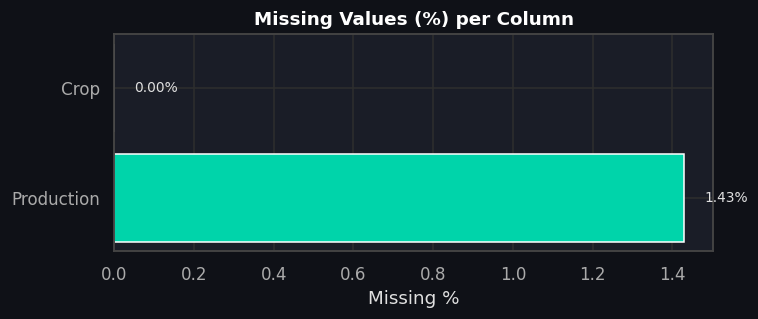

In [8]:
fig, ax = plt.subplots(figsize=(7, 3))
cols_na = mv_df[mv_df['Missing Count'] > 0]
bars = ax.barh(cols_na.index, cols_na['Missing %'], color=ACCENT)
for bar, v in zip(bars, cols_na['Missing %']):
    ax.text(v + 0.05, bar.get_y() + bar.get_height()/2,
            f'{v:.2f}%', va='center', fontsize=9)
ax.set_title('Missing Values (%) per Column', fontweight='bold')
ax.set_xlabel('Missing %')
plt.tight_layout(); plt.show()


### 3.2 Numeric Range Validation


In [9]:
for col in ['Area', 'Production', 'Yield_orig']:
    s = df[col].dropna()
    print(f'{col:15s}  negatives={( s<0).sum():4d}  '
          f'zeros={(s==0).sum():5d}  min={s.min():.3f}  max={s.max():,.0f}')


Area             negatives=   0  zeros=    0  min=0.004  max=8,580,100
Production       negatives=   0  zeros= 1466  min=0.000  max=1,597,800,000
Yield_orig       negatives=   0  zeros= 6096  min=0.000  max=43,958


### 3.3 Unique Categorical Values


In [10]:
for col in ['State_Name', 'District_Name', 'Season', 'Crop']:
    print(f'{col:20s}: {df[col].nunique()} unique')

print('\nSeason values:', df['Season'].unique().tolist())


State_Name          : 37 unique
District_Name       : 707 unique
Season              : 6 unique
Crop                : 55 unique

Season values: ['Kharif     ', 'Rabi       ', 'Autumn     ', 'Summer     ', 'Whole Year ', 'Winter     ']


---
## 4. Feature Engineering


In [11]:
# Work on a clean copy (drop rows with null Production)
df_clean = df.dropna(subset=['Production']).copy()
print(f'Rows kept: {len(df_clean):,}  (dropped {len(df)-len(df_clean):,} null-Production rows)')


Rows kept: 340,388  (dropped 4,948 null-Production rows)


In [13]:
# Yield = Production / Area
df_clean['Yield'] = df_clean['Production'] / df_clean['Area'].replace(0, np.nan)

# Time grouping
df_clean['Decade'] = (df_clean['Crop_Year'] // 10 * 10).astype(str) + 's'

# Clean season labels
df_clean['Season_clean'] = (df_clean['Season']
                             .str.replace(r'\s+', ' ', regex=True)
                             .str.strip().str.title())

# Log transforms for skewed numerics
df_clean['Log_Area']       = np.log1p(df_clean['Area'])
df_clean['Log_Production'] = np.log1p(df_clean['Production'])
df_clean['Log_Yield']      = np.log1p(df_clean['Yield'])

df_clean[['Area','Production','Yield','Decade','Season_clean']].head()


,Area,Production,Yield,Decade,Season_clean
0,2439.6,3415.0,1.399820,2000s,Kharif
1,1626.4,2277.0,1.400025,2000s,Rabi
2,4147.0,3060.0,0.737883,2000s,Autumn
3,4147.0,2660.0,0.641428,2000s,Summer
4,4153.0,3120.0,0.751264,2000s,Autumn


---
## 5. Univariate Analysis


### 5.1 State — Record Frequency


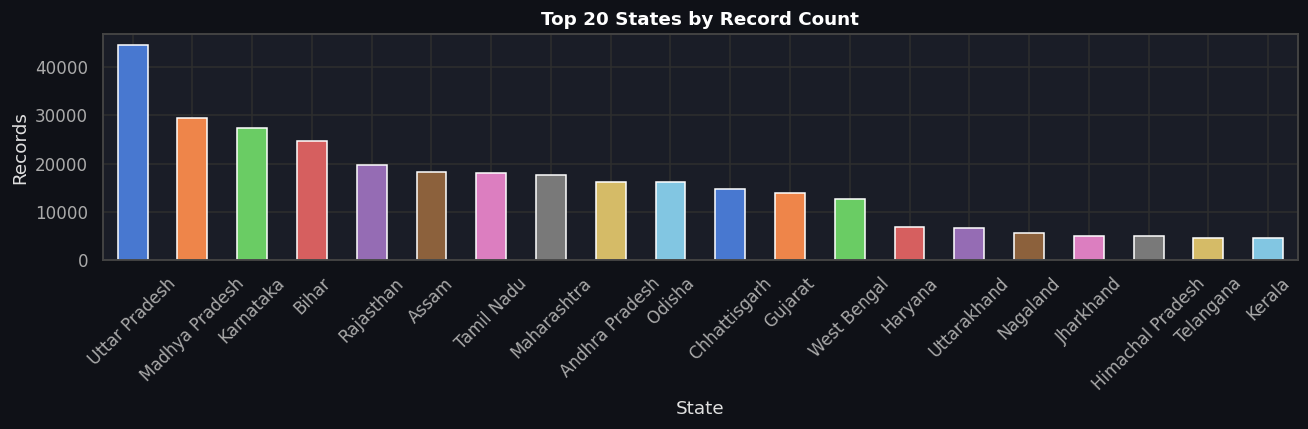

In [14]:
top_states_cnt = df_clean['State_Name'].value_counts().head(20)
fig, ax = plt.subplots(figsize=(12, 4))
top_states_cnt.plot(kind='bar', ax=ax, color=sns.color_palette('muted', 20))
ax.set_title('Top 20 States by Record Count', fontweight='bold')
ax.set_xlabel('State'); ax.set_ylabel('Records')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()


### 5.2 Season Distribution


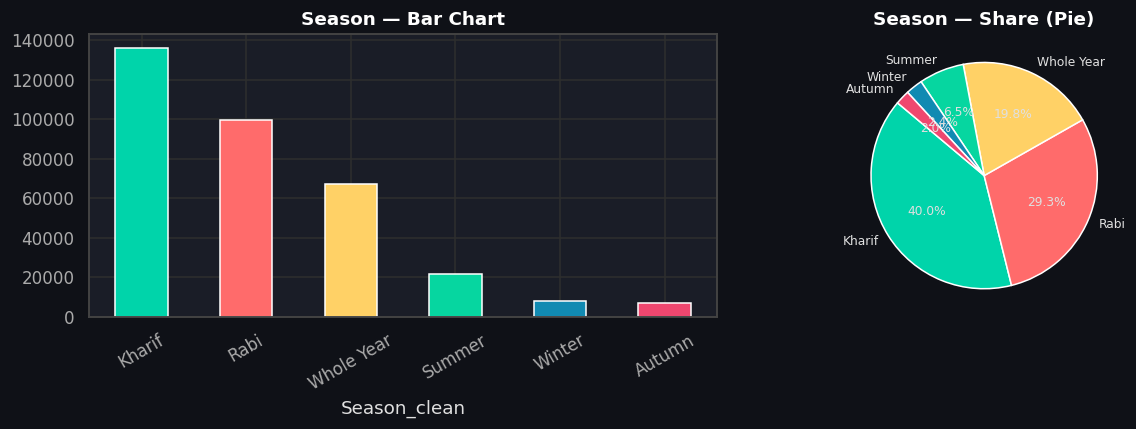

In [15]:
season_cnt = df_clean['Season_clean'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
season_cnt.plot(kind='bar', ax=axes[0], color=PALETTE[:len(season_cnt)])
axes[0].set_title('Season — Bar Chart', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
axes[1].pie(season_cnt, labels=season_cnt.index, autopct='%1.1f%%',
            colors=PALETTE[:len(season_cnt)], startangle=140,
            textprops={'fontsize': 8})
axes[1].set_title('Season — Share (Pie)', fontweight='bold')
plt.tight_layout(); plt.show()


### 5.3 Crop Year Distribution


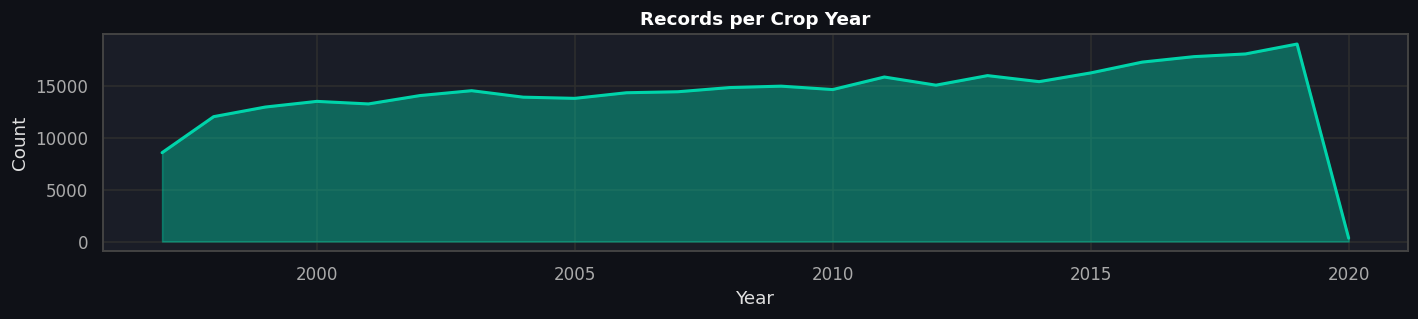

In [16]:
year_cnt = df_clean['Crop_Year'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(13, 3))
ax.fill_between(year_cnt.index, year_cnt.values, alpha=0.4, color=ACCENT)
ax.plot(year_cnt.index, year_cnt.values, color=ACCENT, linewidth=2)
ax.set_title('Records per Crop Year', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Count')
plt.tight_layout(); plt.show()


### 5.4 Top 30 Crops by Frequency


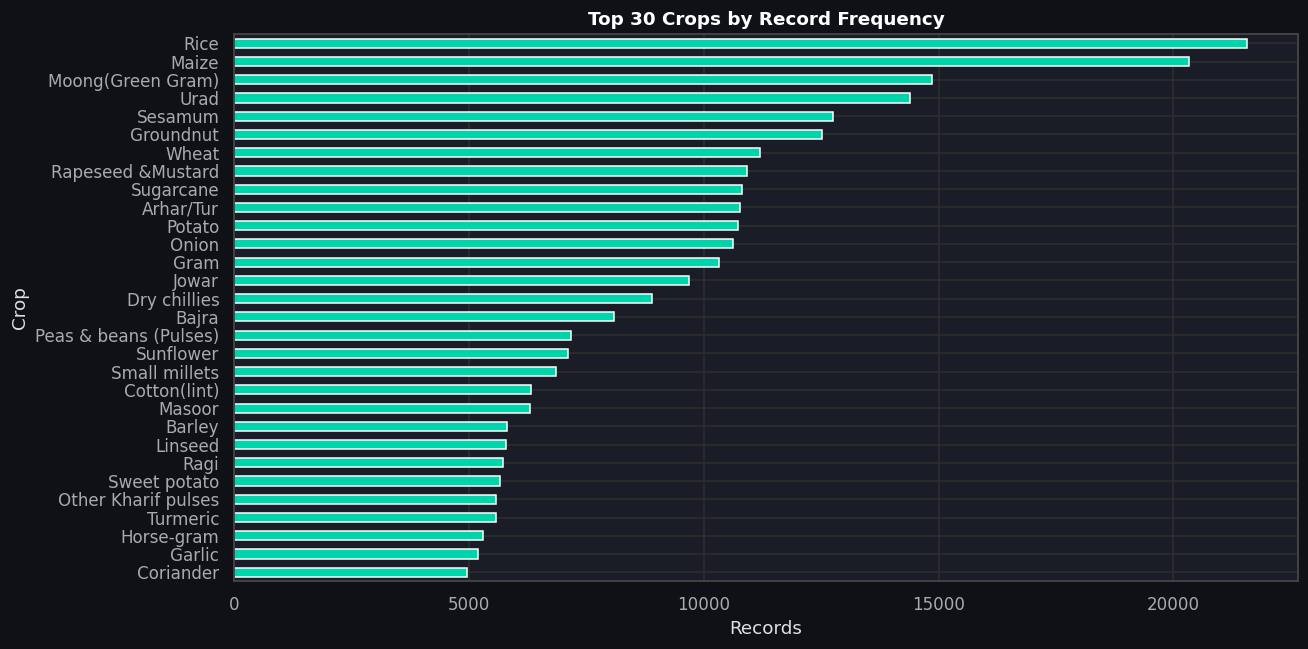

In [17]:
crop_cnt = df_clean['Crop'].value_counts().head(30)
fig, ax = plt.subplots(figsize=(12, 6))
crop_cnt.plot(kind='barh', ax=ax, color=ACCENT)
ax.set_title('Top 30 Crops by Record Frequency', fontweight='bold')
ax.set_xlabel('Records'); ax.invert_yaxis()
plt.tight_layout(); plt.show()


### 5.5 Area — Histogram & Boxplot


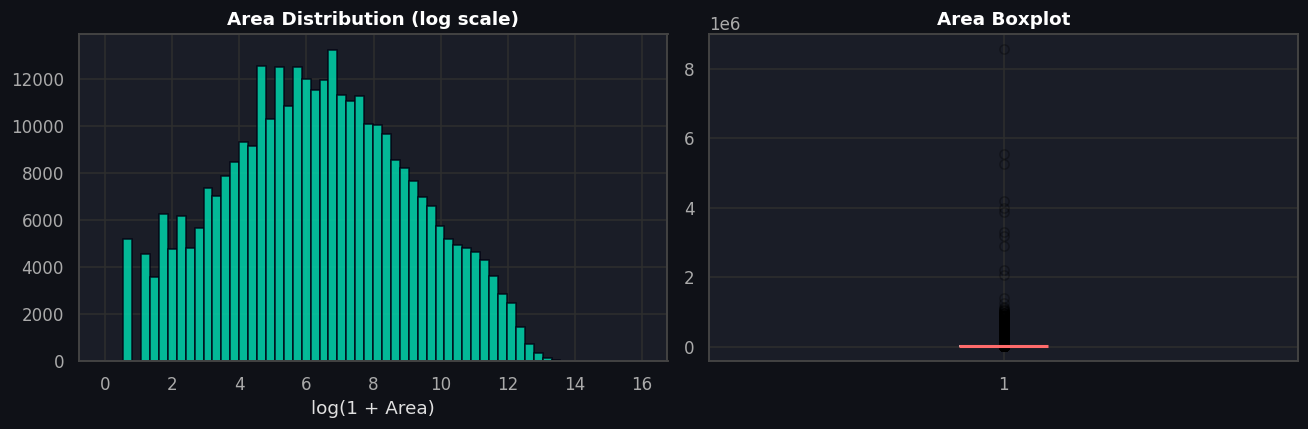

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_clean['Log_Area'].dropna(), bins=60,
             color=ACCENT, edgecolor='#001', alpha=0.85)
axes[0].set_title('Area Distribution (log scale)', fontweight='bold')
axes[0].set_xlabel('log(1 + Area)')
axes[1].boxplot(df_clean['Area'].dropna(), patch_artist=True,
                boxprops=dict(facecolor=ACCENT, color='#e0e0e0'),
                medianprops=dict(color='#ff6b6b', linewidth=2),
                whiskerprops=dict(color='#e0e0e0'),
                capprops=dict(color='#e0e0e0'),
                flierprops=dict(marker='o', color='#ffd166', alpha=0.3))
axes[1].set_title('Area Boxplot', fontweight='bold')
plt.tight_layout(); plt.show()


### 5.6 Production — Histogram & Boxplot


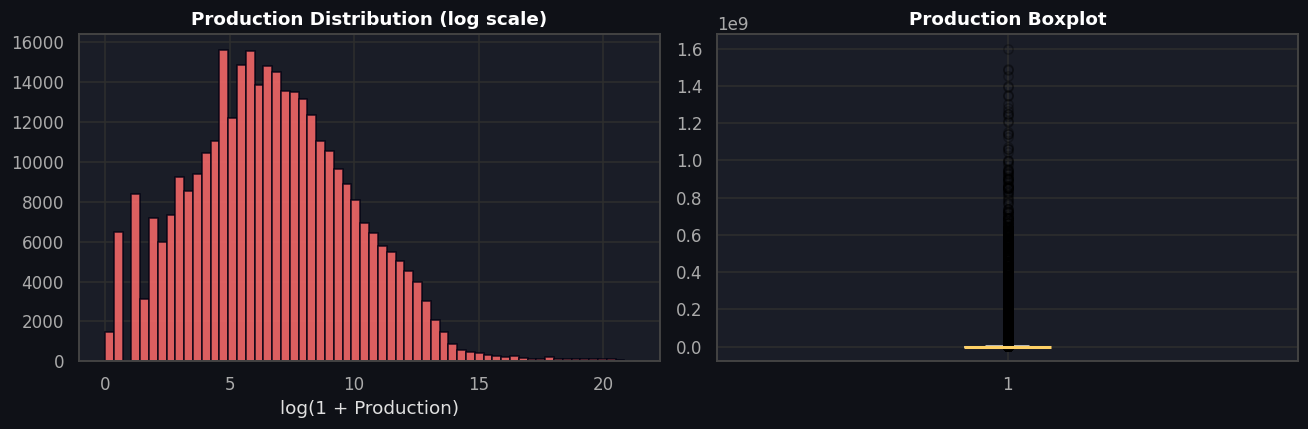

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_clean['Log_Production'].dropna(), bins=60,
             color='#ff6b6b', edgecolor='#001', alpha=0.85)
axes[0].set_title('Production Distribution (log scale)', fontweight='bold')
axes[0].set_xlabel('log(1 + Production)')
axes[1].boxplot(df_clean['Production'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='#ff6b6b', color='#e0e0e0'),
                medianprops=dict(color='#ffd166', linewidth=2),
                whiskerprops=dict(color='#e0e0e0'),
                capprops=dict(color='#e0e0e0'),
                flierprops=dict(marker='o', color='#ffd166', alpha=0.3))
axes[1].set_title('Production Boxplot', fontweight='bold')
plt.tight_layout(); plt.show()


### 5.7 Yield — Distribution


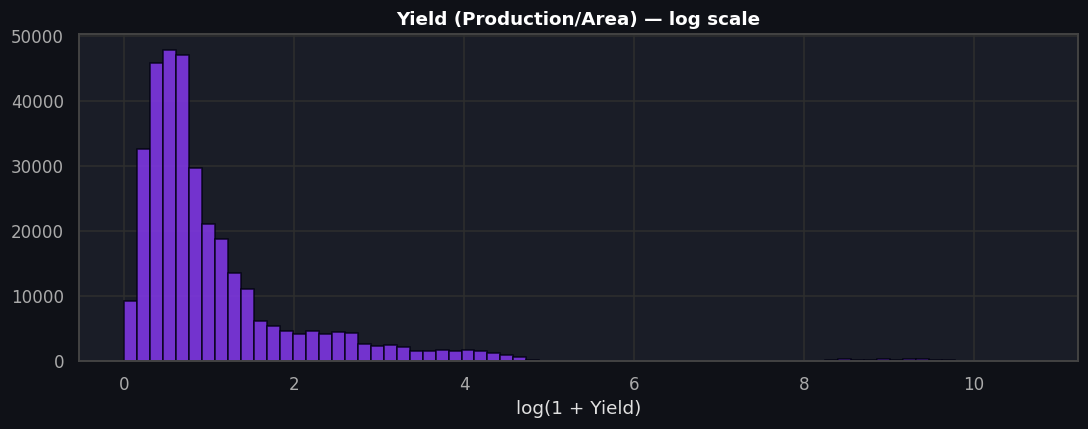

In [20]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_clean['Log_Yield'].dropna(), bins=70,
        color='#8338ec', edgecolor='#001', alpha=0.85)
ax.set_title('Yield (Production/Area) — log scale', fontweight='bold')
ax.set_xlabel('log(1 + Yield)')
plt.tight_layout(); plt.show()


---
## 6. Outlier Detection


### 6.1 IQR Method — Summary


In [21]:
def iqr_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n = ((series < lo) | (series > hi)).sum()
    return lo, hi, n, n/len(series)*100

rows = []
for col in ['Area', 'Production', 'Yield']:
    lo, hi, n, pct = iqr_outliers(df_clean[col].dropna())
    rows.append({'Column': col, 'Lower Fence': round(lo,2),
                 'Upper Fence': round(hi,2), 'Outliers': n, 'Outlier %': round(pct,2)})
pd.DataFrame(rows)


,Column,Lower Fence,Upper Fence,Outliers,Outlier %
0,Area,-6187.00,10525.0,56520,16.60
1,Production,-10555.50,17824.5,60094,17.65
2,Yield,-2.33,5.4,51383,15.10


### 6.2 Boxplots — Area, Production, Yield


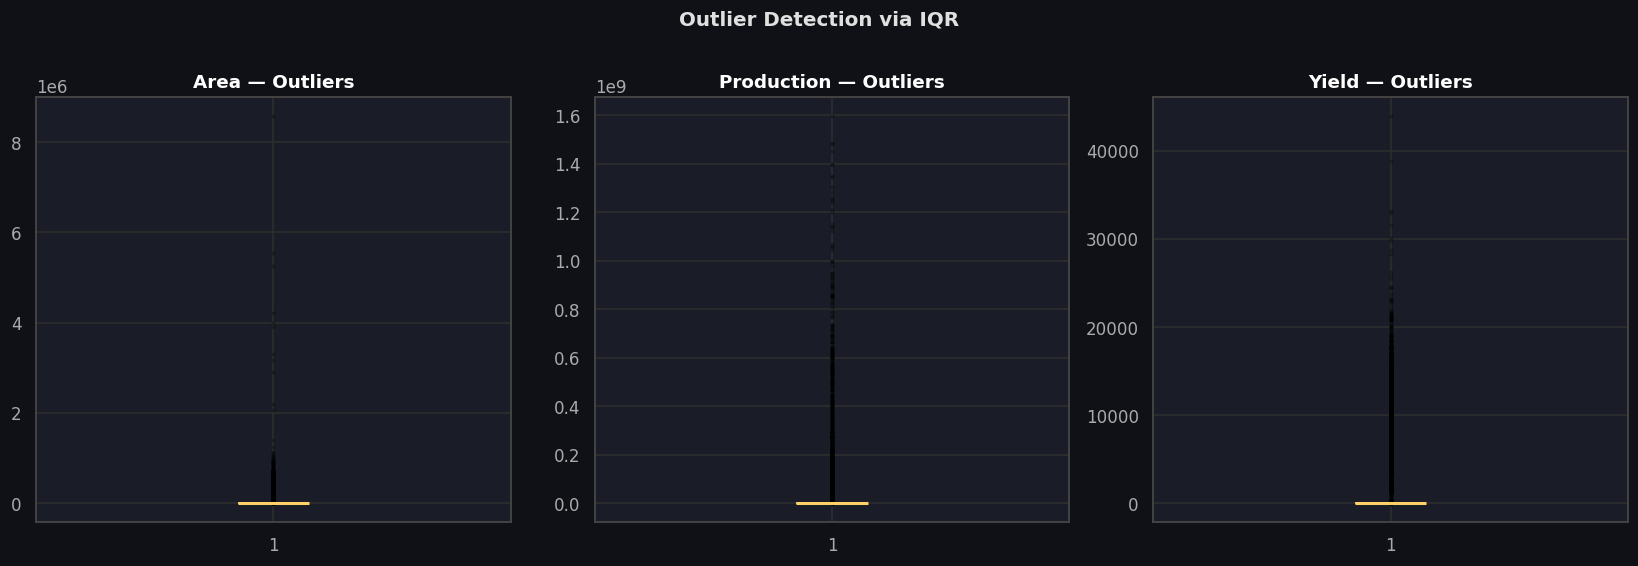

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col, color in zip(axes,
                           ['Area', 'Production', 'Yield'],
                           [ACCENT, '#ff6b6b', '#8338ec']):
    ax.boxplot(df_clean[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=color, color='#e0e0e0'),
               medianprops=dict(color='#ffd166', linewidth=2),
               whiskerprops=dict(color='#e0e0e0'),
               capprops=dict(color='#e0e0e0'),
               flierprops=dict(marker='.', color=color, alpha=0.3, markersize=3))
    ax.set_title(f'{col} — Outliers', fontweight='bold')
plt.suptitle('Outlier Detection via IQR', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


### 6.3 Extreme Records


In [23]:
print('Top 5 by Production:')
display(df_clean.nlargest(5, 'Production')
        [['State_Name','Crop','Crop_Year','Season_clean','Area','Production']])

print('\nTop 5 by Area:')
display(df_clean.nlargest(5, 'Area')
        [['State_Name','Crop','Crop_Year','Season_clean','Area','Production']])


Top 5 by Production:


,State_Name,Crop,Crop_Year,Season_clean,Area,Production
258831,Tamil Nadu,Coconut,2007,Whole Year,107106.0,1.597800e+09
258841,Tamil Nadu,Coconut,2019,Whole Year,87749.0,1.488200e+09
258830,Tamil Nadu,Coconut,2006,Whole Year,104197.0,1.482900e+09
120685,Karnataka,Coconut,2019,Whole Year,176243.0,1.452725e+09
258837,Tamil Nadu,Coconut,2015,Whole Year,85448.0,1.401300e+09



Top 5 by Area:


,State_Name,Crop,Crop_Year,Season_clean,Area,Production
339271,West Bengal,Niger seed,1997,Rabi,8580100.0,7556300.0
339270,West Bengal,Niger seed,1997,Rabi,5544000.0,4485800.0
339269,West Bengal,Niger seed,1997,Rabi,5251200.0,3519600.0
339256,West Bengal,Niger seed,1997,Rabi,4205800.0,3183800.0
339272,West Bengal,Niger seed,1997,Rabi,3989200.0,2899500.0


---
## 7. Bivariate Analysis


### 7.1 Area vs Production (scatter — log scale)


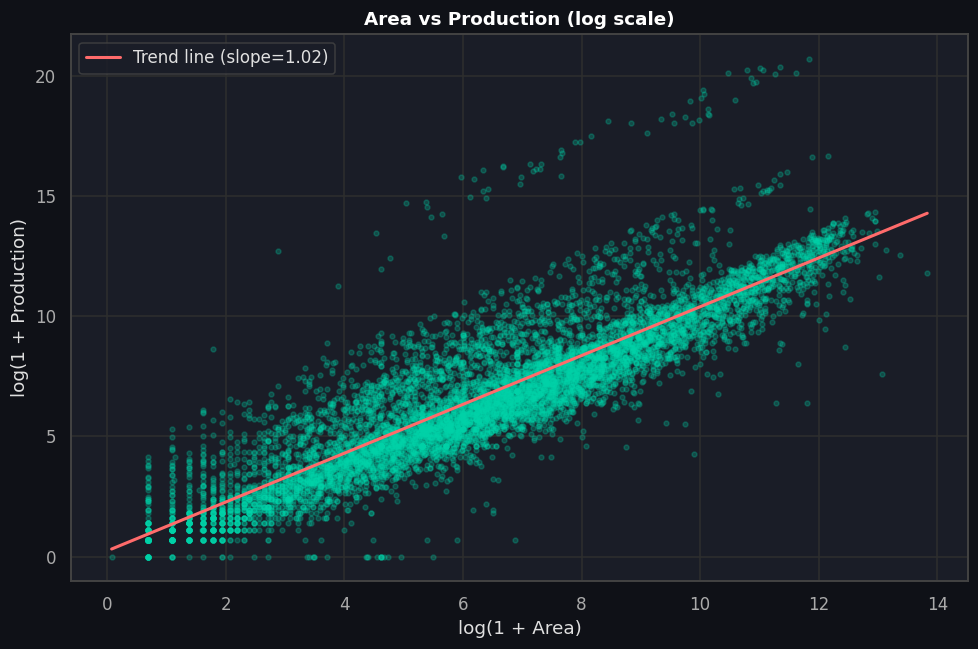

In [24]:
sample = (df_clean[['Log_Area','Log_Production']]
          .dropna()
          .sample(min(8000, len(df_clean)), random_state=42))
m, b = np.polyfit(sample['Log_Area'], sample['Log_Production'], 1)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(sample['Log_Area'], sample['Log_Production'],
           alpha=0.25, s=10, color=ACCENT)
x = np.linspace(sample['Log_Area'].min(), sample['Log_Area'].max(), 100)
ax.plot(x, m*x+b, color='#ff6b6b', linewidth=2,
        label=f'Trend line (slope={m:.2f})')
ax.set_xlabel('log(1 + Area)'); ax.set_ylabel('log(1 + Production)')
ax.set_title('Area vs Production (log scale)', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()


### 7.2 Top 10 Crops by Median Production


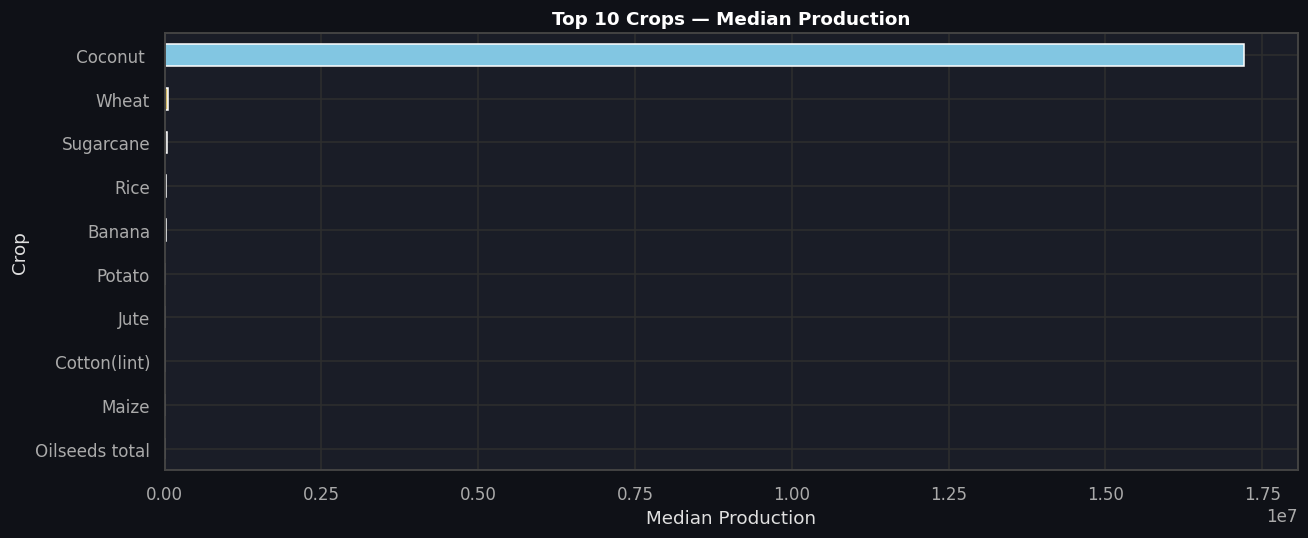

In [25]:
top10_crops = df_clean.groupby('Crop')['Production'].median().nlargest(10)
fig, ax = plt.subplots(figsize=(12, 5))
top10_crops.sort_values().plot(kind='barh', ax=ax,
                               color=sns.color_palette('muted', 10))
ax.set_title('Top 10 Crops — Median Production', fontweight='bold')
ax.set_xlabel('Median Production')
plt.tight_layout(); plt.show()


### 7.3 Production by Season (boxplot)


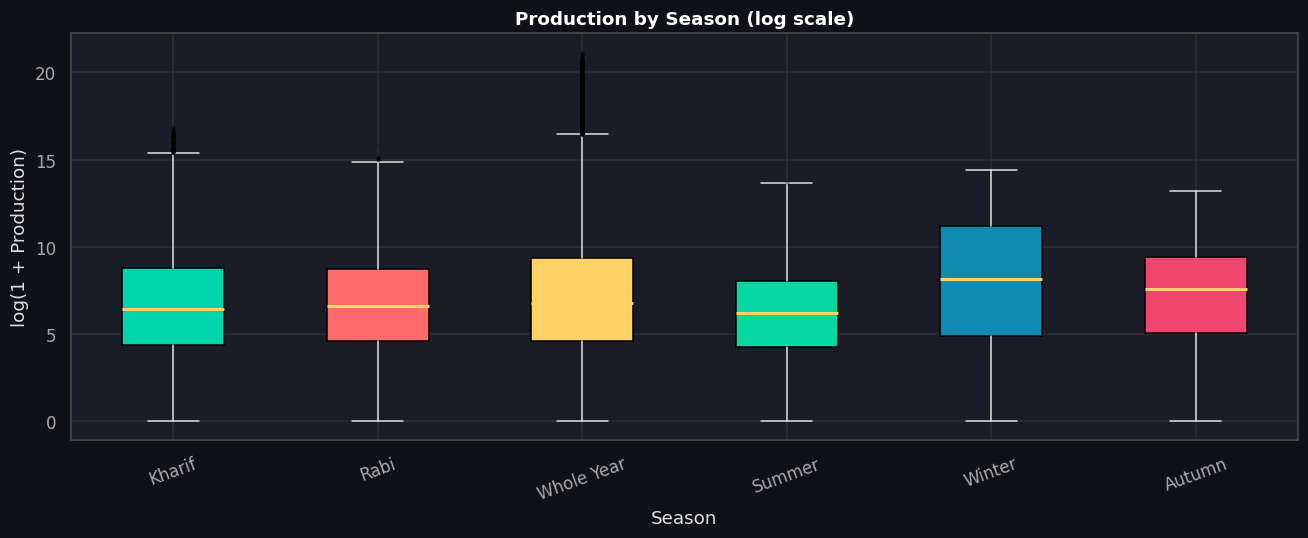

In [26]:
top_seasons = df_clean['Season_clean'].value_counts().head(6).index
data_by_season = [
    df_clean.loc[df_clean['Season_clean']==s, 'Log_Production'].dropna().values
    for s in top_seasons]

fig, ax = plt.subplots(figsize=(12, 5))
bp = ax.boxplot(data_by_season, labels=top_seasons, patch_artist=True,
                medianprops=dict(color='#ffd166', linewidth=2),
                whiskerprops=dict(color='#e0e0e0'),
                capprops=dict(color='#e0e0e0'),
                flierprops=dict(marker='.', alpha=0.2, markersize=3))
for patch, c in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(c)
ax.set_title('Production by Season (log scale)', fontweight='bold')
ax.set_xlabel('Season'); ax.set_ylabel('log(1 + Production)')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()


### 7.4 Top 15 States by Total Production


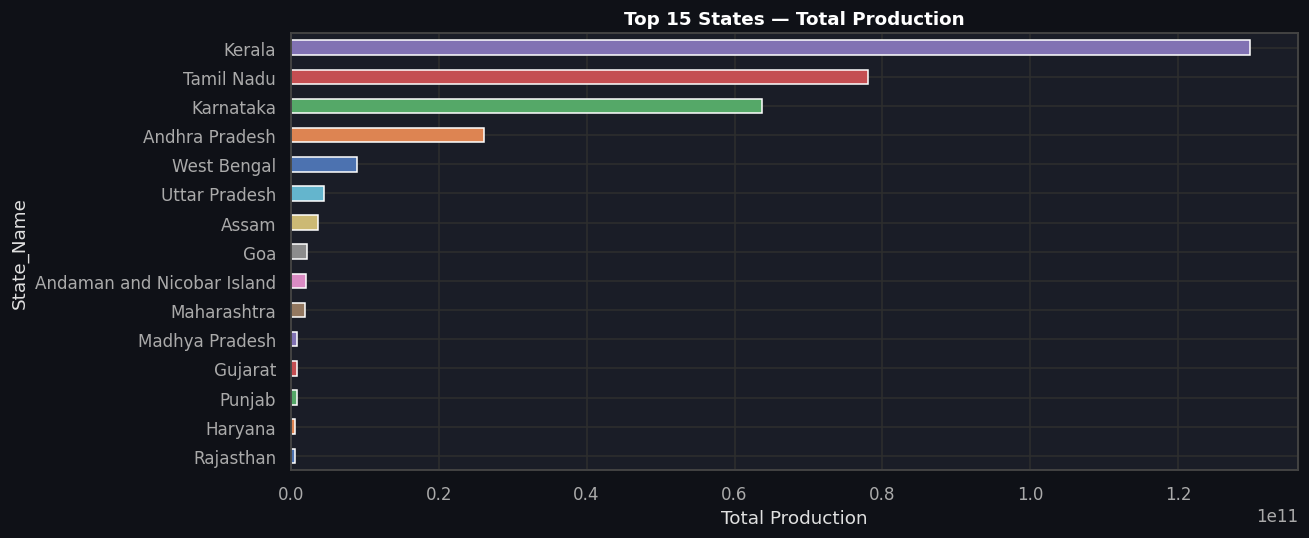

In [27]:
top15_states = (df_clean.groupby('State_Name')['Production']
                .sum().nlargest(15))
fig, ax = plt.subplots(figsize=(12, 5))
top15_states.sort_values().plot(kind='barh', ax=ax,
                                color=sns.color_palette('deep', 15))
ax.set_title('Top 15 States — Total Production', fontweight='bold')
ax.set_xlabel('Total Production')
plt.tight_layout(); plt.show()


### 7.5 Top 10 Crops × Top 5 States — Grouped Bar


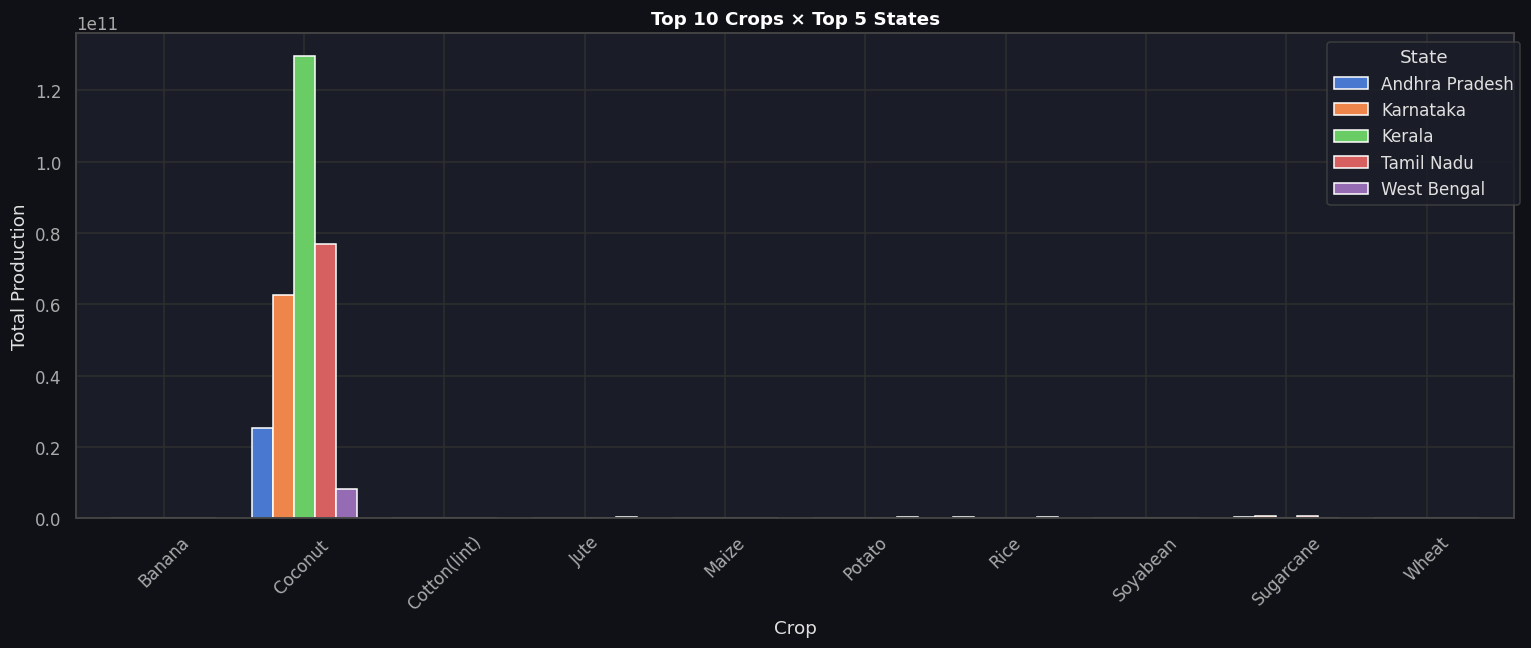

In [28]:
top5_states  = df_clean.groupby('State_Name')['Production'].sum().nlargest(5).index
top10_crops_l = df_clean.groupby('Crop')['Production'].sum().nlargest(10).index

pivot = (df_clean[df_clean['State_Name'].isin(top5_states) &
                  df_clean['Crop'].isin(top10_crops_l)]
         .groupby(['State_Name','Crop'])['Production'].sum()
         .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(14, 6))
pivot.T.plot(kind='bar', ax=ax, width=0.75)
ax.set_title('Top 10 Crops × Top 5 States', fontweight='bold')
ax.set_xlabel('Crop'); ax.set_ylabel('Total Production')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='State', bbox_to_anchor=(1.01,1))
plt.tight_layout(); plt.show()


---
## 8. Multivariate Analysis


### 8.1 Correlation Heatmap


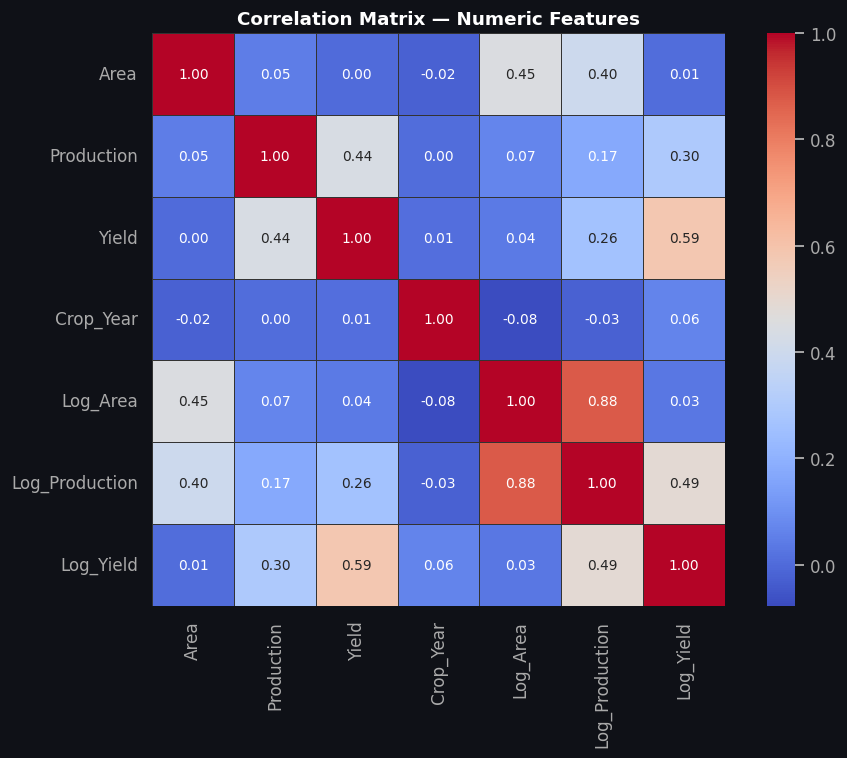

In [29]:
num_cols = ['Area','Production','Yield','Crop_Year',
            'Log_Area','Log_Production','Log_Yield']
corr = df_clean[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax,
            linewidths=0.5, linecolor='#333', annot_kws={'size': 9},
            square=True)
ax.set_title('Correlation Matrix — Numeric Features', fontweight='bold')
plt.tight_layout(); plt.show()


### 8.2 Pairplot by Season


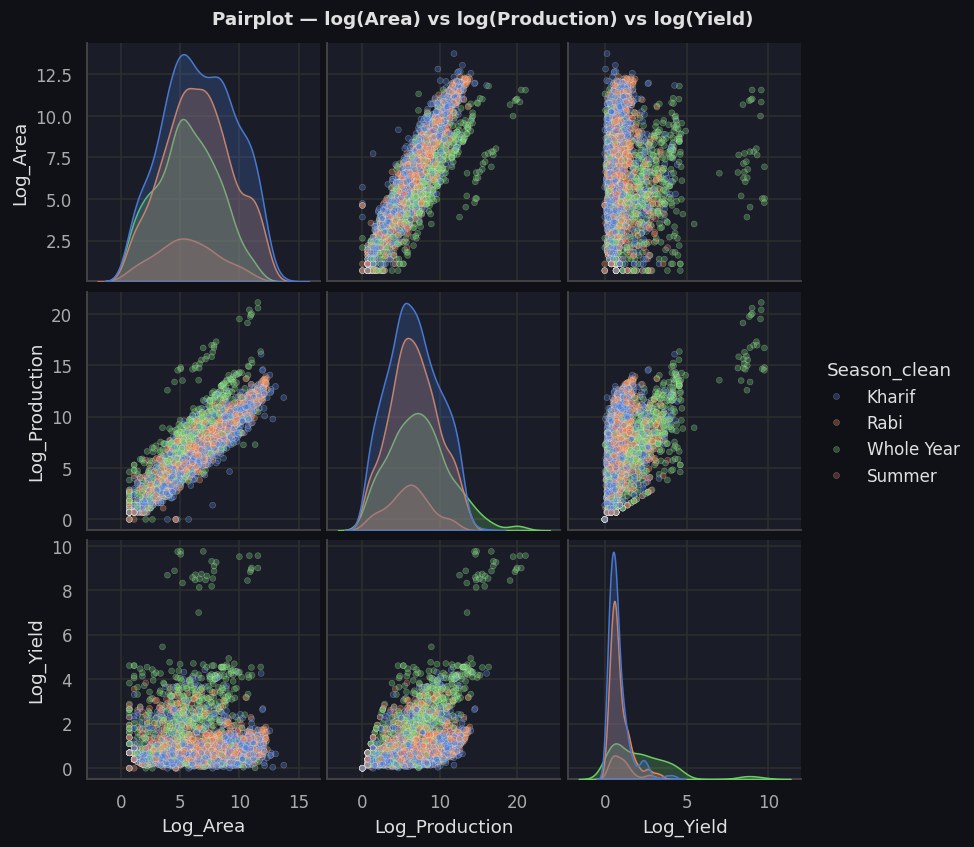

In [30]:
top4_seasons = df_clean['Season_clean'].value_counts().head(4).index
pair_df = (df_clean[df_clean['Season_clean'].isin(top4_seasons)]
           [['Log_Area','Log_Production','Log_Yield','Season_clean']]
           .dropna()
           .sample(3000, random_state=42))

g = sns.pairplot(pair_df, hue='Season_clean',
                 plot_kws={'alpha': 0.35, 's': 15},
                 diag_kind='kde', palette='muted')
g.figure.suptitle('Pairplot — log(Area) vs log(Production) vs log(Yield)',
                   y=1.02, fontsize=12, fontweight='bold')
plt.show()


### 8.3 Decade × Season Heatmap


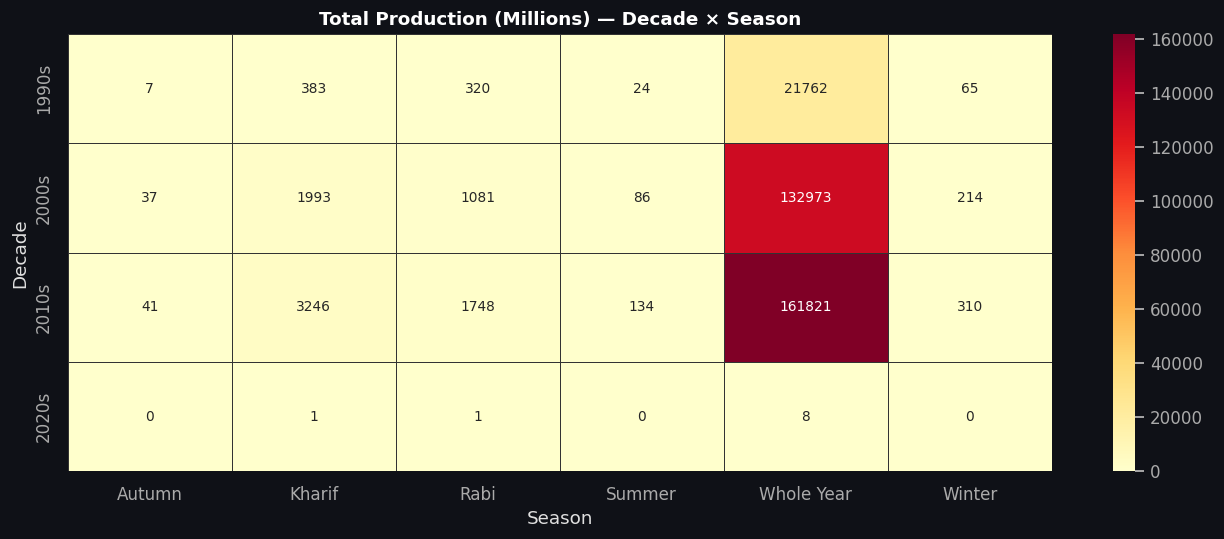

In [31]:
pivot_hm = (df_clean.groupby(['Decade','Season_clean'])['Production']
            .sum().unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot_hm/1e6, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, linecolor='#333', annot_kws={'size': 9})
ax.set_title('Total Production (Millions) — Decade × Season', fontweight='bold')
ax.set_xlabel('Season'); ax.set_ylabel('Decade')
plt.tight_layout(); plt.show()


---
## 9. Geographic Analysis


### 9.1 Top Producing States


In [32]:
top_states_prod = (df_clean.groupby('State_Name')['Production']
                   .sum().nlargest(15).reset_index())
top_states_prod.columns = ['State', 'Total_Production']
top_states_prod['Total_Production_M'] = (top_states_prod['Total_Production']/1e6).round(2)
display(top_states_prod)


,State,Total_Production,Total_Production_M
0,Kerala,1.297006e+11,129700.65
1,Tamil Nadu,7.805176e+10,78051.76
2,Karnataka,6.377280e+10,63772.80
3,Andhra Pradesh,2.607622e+10,26076.22
4,West Bengal,8.941179e+09,8941.18
5,Uttar Pradesh,4.442585e+09,4442.59
6,Assam,3.637715e+09,3637.71
7,Goa,2.193998e+09,2194.00
8,Andaman and Nicobar Island,2.053350e+09,2053.35
9,Maharashtra,1.878565e+09,1878.56


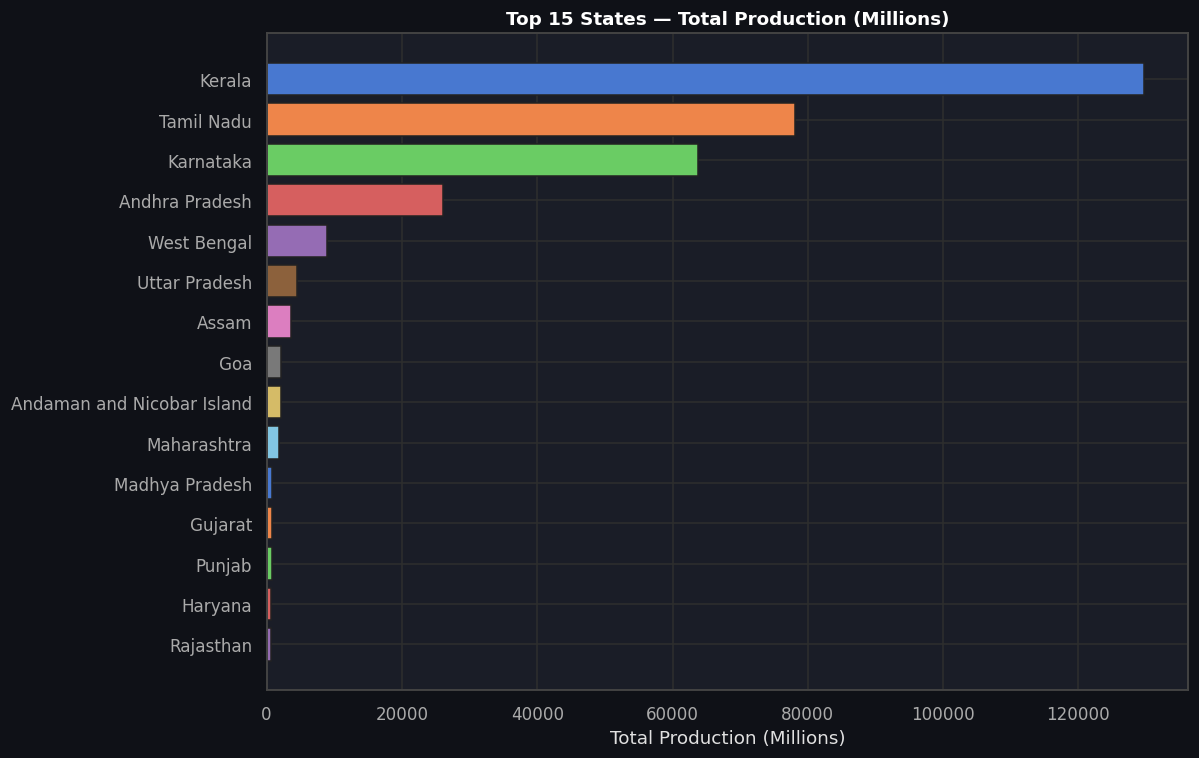

In [33]:
fig, ax = plt.subplots(figsize=(11, 7))
colors = sns.color_palette('muted', len(top_states_prod))
ax.barh(top_states_prod['State'], top_states_prod['Total_Production_M'],
        color=colors, edgecolor='#222')
ax.set_title('Top 15 States — Total Production (Millions)', fontweight='bold')
ax.set_xlabel('Total Production (Millions)')
ax.invert_yaxis()
plt.tight_layout(); plt.show()


### 9.2 Top Crops in India


In [34]:
top_crops_prod = (df_clean.groupby('Crop')['Production']
                  .sum().nlargest(10).reset_index())
top_crops_prod.columns = ['Crop','Total_Production']
top_crops_prod['Total_Production_M'] = (top_crops_prod['Total_Production']/1e6).round(2)
display(top_crops_prod)


,Crop,Total_Production,Total_Production_M
0,Coconut,3.108048e+11,310804.77
1,Sugarcane,7.249507e+09,7249.51
2,Rice,2.236428e+09,2236.43
3,Wheat,2.007360e+09,2007.36
4,Potato,6.323157e+08,632.32
5,Cotton(lint),4.839080e+08,483.91
6,Maize,4.440007e+08,444.00
7,Jute,2.304238e+08,230.42
8,Banana,2.267633e+08,226.76
9,Soyabean,2.117965e+08,211.80


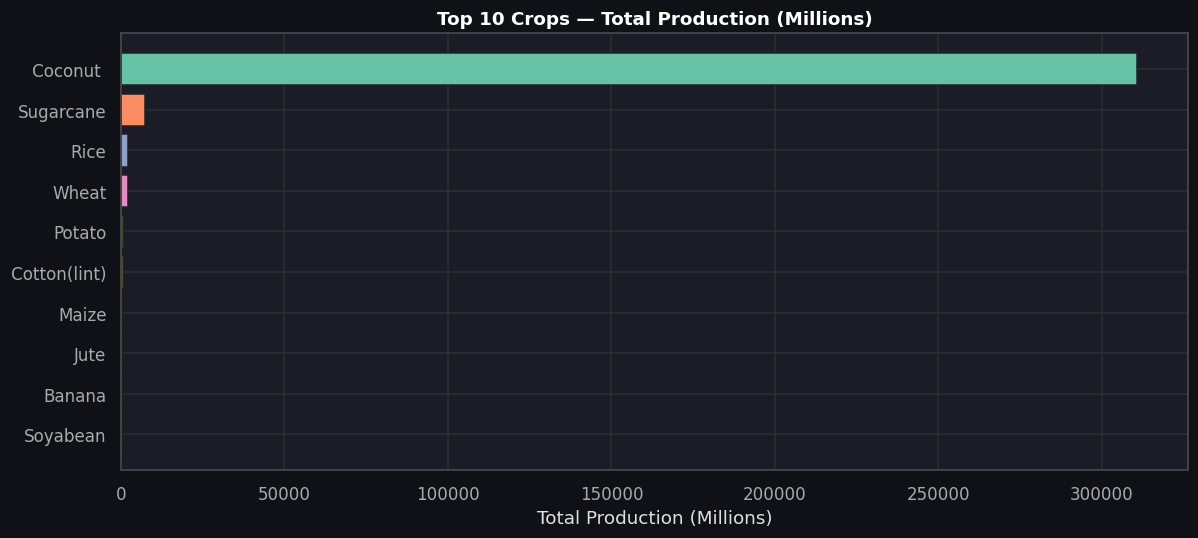

In [35]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(top_crops_prod['Crop'], top_crops_prod['Total_Production_M'],
        color=sns.color_palette('Set2', 10), edgecolor='#222')
ax.set_title('Top 10 Crops — Total Production (Millions)', fontweight='bold')
ax.set_xlabel('Total Production (Millions)')
ax.invert_yaxis()
plt.tight_layout(); plt.show()


### 9.3 Production by Season


In [36]:
season_prod = (df_clean.groupby('Season_clean')['Production']
               .sum().sort_values(ascending=False).reset_index())
season_prod['Production_M'] = (season_prod['Production']/1e6).round(2)
display(season_prod)


,Season_clean,Production,Production_M
0,Whole Year,3.165636e+11,316563.64
1,Kharif,5.622335e+09,5622.33
2,Rabi,3.150455e+09,3150.45
3,Winter,5.877505e+08,587.75
4,Summer,2.437629e+08,243.76
5,Autumn,8.464151e+07,84.64


### 9.4 Season × Decade — Stacked Bar


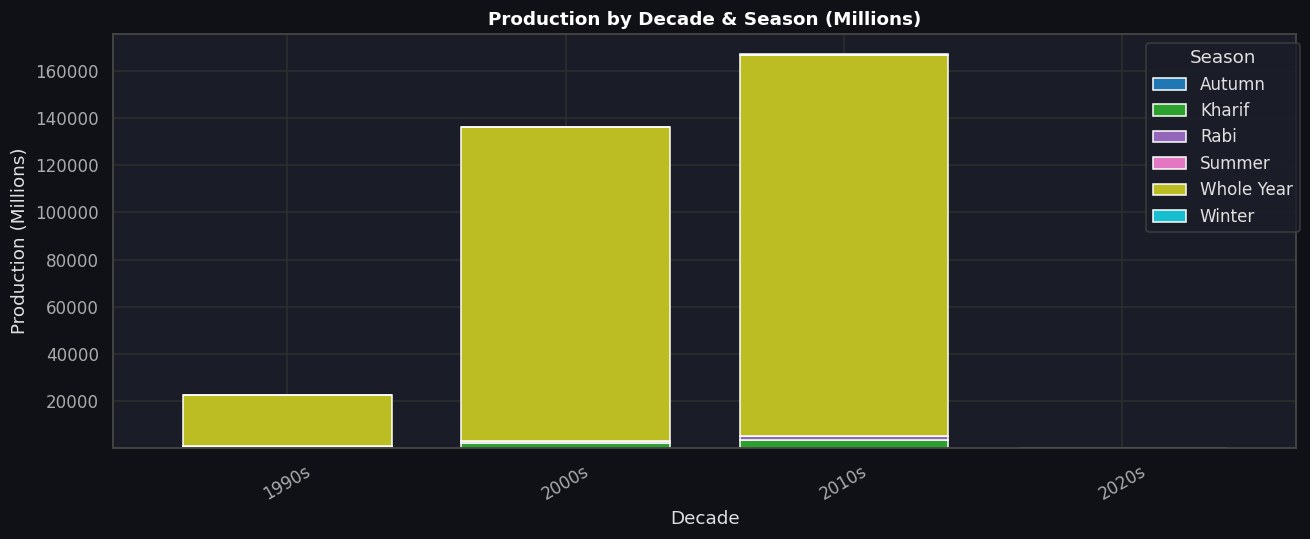

In [37]:
pivot_s = (df_clean.groupby(['Decade','Season_clean'])['Production']
           .sum().unstack(fill_value=0) / 1e6)
fig, ax = plt.subplots(figsize=(12, 5))
pivot_s.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', width=0.75)
ax.set_title('Production by Decade & Season (Millions)', fontweight='bold')
ax.set_xlabel('Decade'); ax.set_ylabel('Production (Millions)')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Season', bbox_to_anchor=(1.01,1))
plt.tight_layout(); plt.show()


### 9.5 State-Wise Crop Specialization (Top Crop per State)


In [38]:
spec = (df_clean.groupby(['State_Name','Crop'])['Production'].sum()
        .reset_index().sort_values('Production', ascending=False)
        .groupby('State_Name').first().reset_index()
        [['State_Name','Crop','Production']]
        .sort_values('Production', ascending=False))
spec['Production_M'] = (spec['Production']/1e6).round(2)
display(spec.drop(columns='Production'))


,State_Name,Crop,Production_M
17,Kerala,Coconut,129607.12
31,Tamil Nadu,Coconut,77024.40
16,Karnataka,Coconut,62692.17
1,Andhra Pradesh,Coconut,25212.33
36,West Bengal,Coconut,8068.33
3,Assam,Coconut,3455.43
34,Uttar Pradesh,Sugarcane,3062.49
10,Goa,Coconut,2188.98
0,Andaman and Nicobar Island,Coconut,2052.31
20,Maharashtra,Sugarcane,1396.76


---
## 10. Temporal Analysis


In [39]:
yearly = df_clean.groupby('Crop_Year').agg(
    Total_Production=('Production','sum'),
    Total_Area=('Area','sum'),
    Mean_Yield=('Yield','mean'),
    Records=('Production','count')
).reset_index()
yearly.head()


,Crop_Year,Total_Production,Total_Area,Mean_Yield,Records
0,1997,6.105673e+09,1.821983e+08,55.269651,8548
1,1998,7.887213e+09,1.678273e+08,51.621298,12013
2,1999,8.566817e+09,1.651038e+08,53.525183,12937
3,2000,9.666098e+09,1.653989e+08,63.919919,13483
4,2001,9.423699e+09,1.648335e+08,64.823917,13237


### 10.1 Total Production over Time


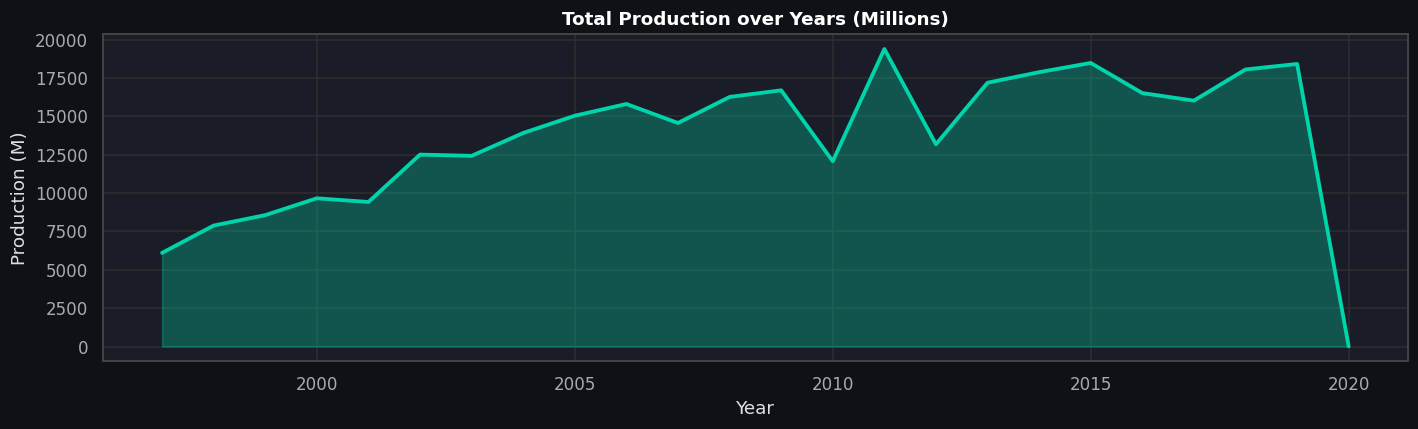

In [40]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(yearly['Crop_Year'], yearly['Total_Production']/1e6,
                alpha=0.3, color=ACCENT)
ax.plot(yearly['Crop_Year'], yearly['Total_Production']/1e6,
        color=ACCENT, linewidth=2.5)
ax.set_title('Total Production over Years (Millions)', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Production (M)')
plt.tight_layout(); plt.show()


### 10.2 Total Area Cultivated over Time


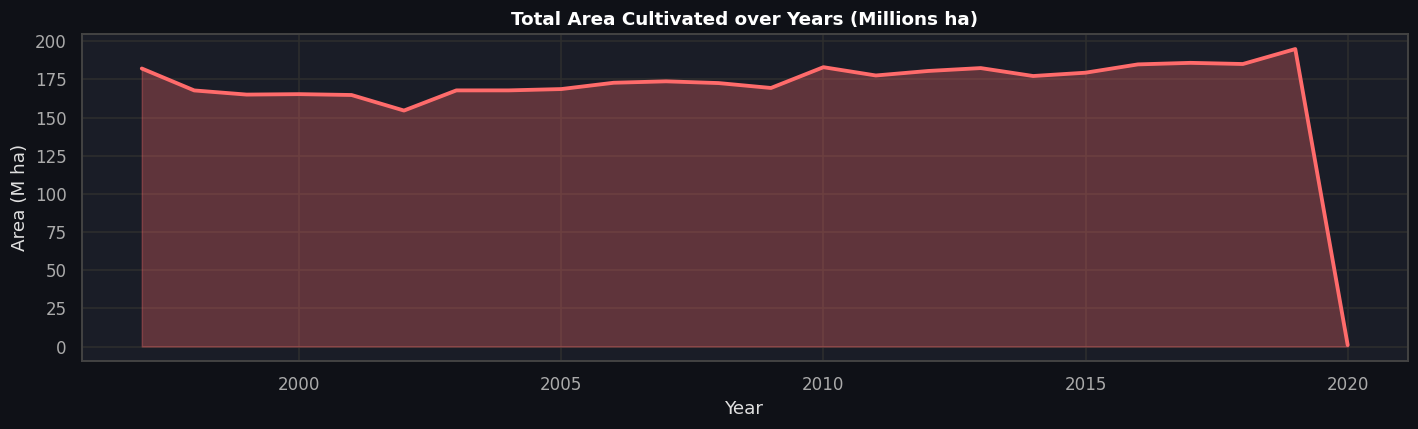

In [41]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(yearly['Crop_Year'], yearly['Total_Area']/1e6,
                alpha=0.3, color='#ff6b6b')
ax.plot(yearly['Crop_Year'], yearly['Total_Area']/1e6,
        color='#ff6b6b', linewidth=2.5)
ax.set_title('Total Area Cultivated over Years (Millions ha)', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Area (M ha)')
plt.tight_layout(); plt.show()


### 10.3 Mean Yield over Time


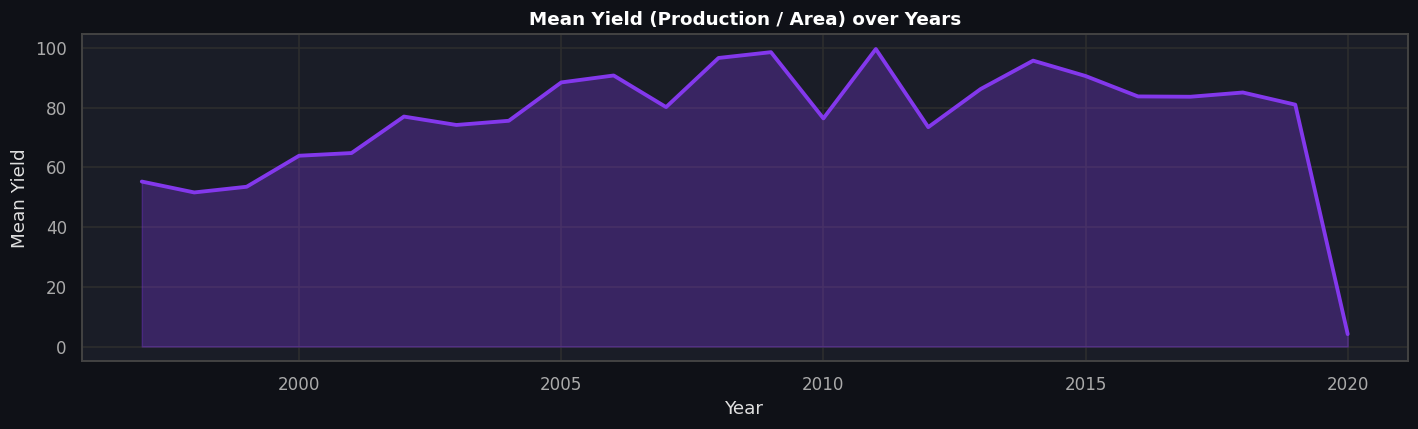

In [42]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(yearly['Crop_Year'], yearly['Mean_Yield'],
                alpha=0.3, color='#8338ec')
ax.plot(yearly['Crop_Year'], yearly['Mean_Yield'],
        color='#8338ec', linewidth=2.5)
ax.set_title('Mean Yield (Production / Area) over Years', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Mean Yield')
plt.tight_layout(); plt.show()


### 10.4 Top 5 Crops — Production Trend


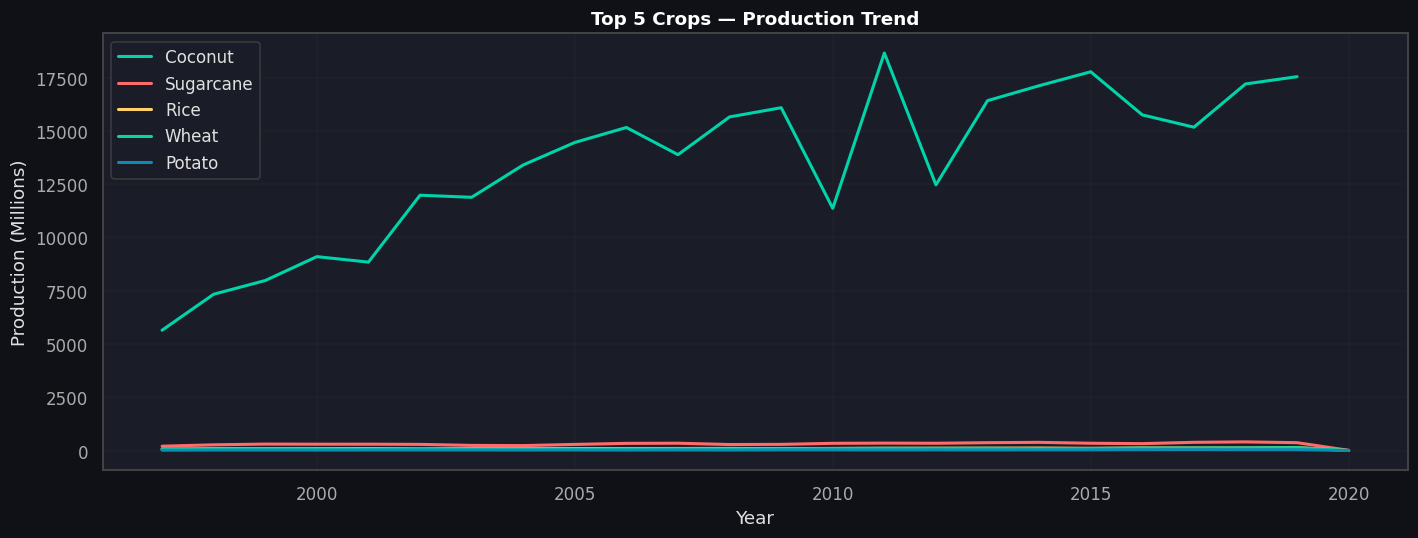

In [43]:
top5_crops = df_clean.groupby('Crop')['Production'].sum().nlargest(5).index
crop_trend = (df_clean[df_clean['Crop'].isin(top5_crops)]
              .groupby(['Crop_Year','Crop'])['Production'].sum().reset_index())

fig, ax = plt.subplots(figsize=(13, 5))
for crop, color in zip(top5_crops, PALETTE):
    d = crop_trend[crop_trend['Crop']==crop]
    ax.plot(d['Crop_Year'], d['Production']/1e6,
            label=crop, color=color, linewidth=2)
ax.set_title('Top 5 Crops — Production Trend', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Production (Millions)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


### 10.5 Top 5 Crops — Area Cultivated Trend


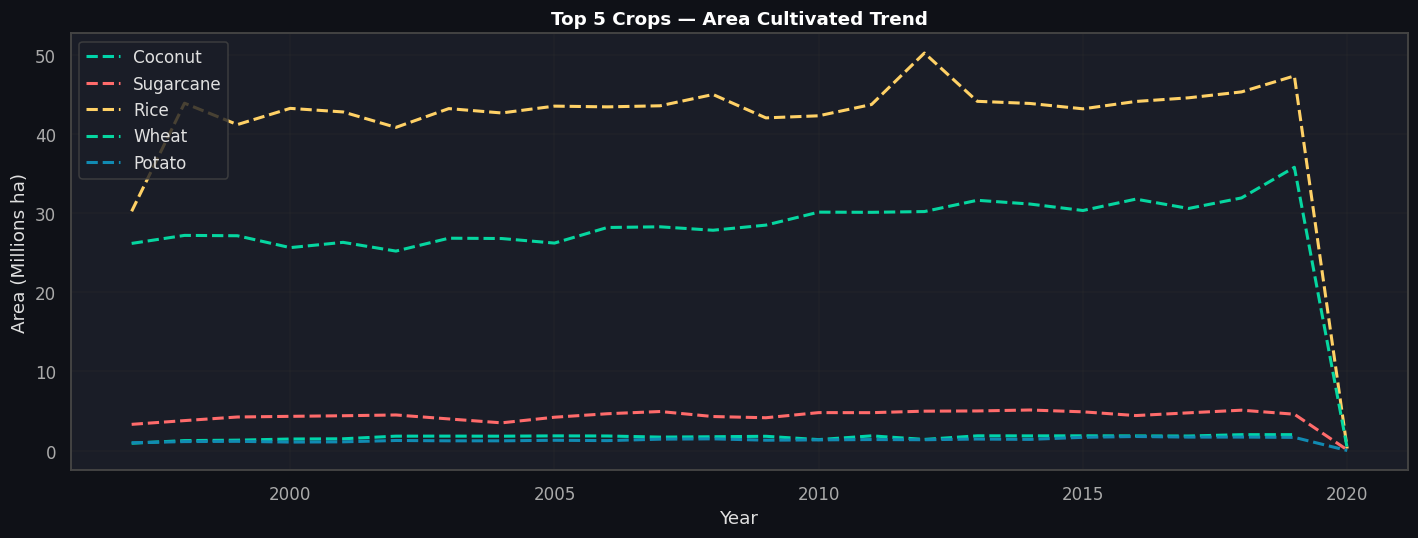

In [44]:
crop_area_trend = (df_clean[df_clean['Crop'].isin(top5_crops)]
                   .groupby(['Crop_Year','Crop'])['Area'].sum().reset_index())

fig, ax = plt.subplots(figsize=(13, 5))
for crop, color in zip(top5_crops, PALETTE):
    d = crop_area_trend[crop_area_trend['Crop']==crop]
    ax.plot(d['Crop_Year'], d['Area']/1e6,
            label=crop, color=color, linewidth=2, linestyle='--')
ax.set_title('Top 5 Crops — Area Cultivated Trend', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Area (Millions ha)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


---
## 11. Key Insights Summary


In [45]:
print('=' * 65)
print('TOP 10 CROPS BY TOTAL PRODUCTION')
print('=' * 65)
t10 = df_clean.groupby('Crop')['Production'].sum().nlargest(10)
for i, (crop, prod) in enumerate(t10.items(), 1):
    print(f'  {i:2d}. {crop:<35} {prod/1e6:10.2f}M')

print()
print('=' * 65)
print('TOP 10 STATES BY TOTAL PRODUCTION')
print('=' * 65)
t10s = df_clean.groupby('State_Name')['Production'].sum().nlargest(10)
for i, (state, prod) in enumerate(t10s.items(), 1):
    print(f'  {i:2d}. {state:<35} {prod/1e6:10.2f}M')

print()
print('=' * 65)
print('PRODUCTION BY SEASON')
print('=' * 65)
sp = df_clean.groupby('Season_clean')['Production'].sum().sort_values(ascending=False)
for s, v in sp.items():
    print(f'  {s:<25} {v/1e6:10.2f}M')

print()
print('ANOMALIES')
row = df_clean.loc[df_clean['Production'].idxmax()]
print(f'  Highest Production: {row["Production"]:,.0f} '
      f'({row["Crop"]}, {row["State_Name"]}, {int(row["Crop_Year"])})')
row2 = df_clean.loc[df_clean['Yield'].idxmax()]
print(f'  Highest Yield     : {row2["Yield"]:,.2f} '
      f'({row2["Crop"]}, {row2["State_Name"]}, {int(row2["Crop_Year"])})')


TOP 10 CROPS BY TOTAL PRODUCTION
   1. Coconut                              310804.77M
   2. Sugarcane                              7249.51M
   3. Rice                                   2236.43M
   4. Wheat                                  2007.36M
   5. Potato                                  632.32M
   6. Cotton(lint)                            483.91M
   7. Maize                                   444.00M
   8. Jute                                    230.42M
   9. Banana                                  226.76M
  10. Soyabean                                211.80M

TOP 10 STATES BY TOTAL PRODUCTION
   1. Kerala                               129700.65M
   2. Tamil Nadu                            78051.76M
   3. Karnataka                             63772.80M
   4. Andhra Pradesh                        26076.22M
   5. West Bengal                            8941.18M
   6. Uttar Pradesh                          4442.59M
   7. Assam                                  3637.71M
   8. Goa     

---
## 12. Visualization Dashboard


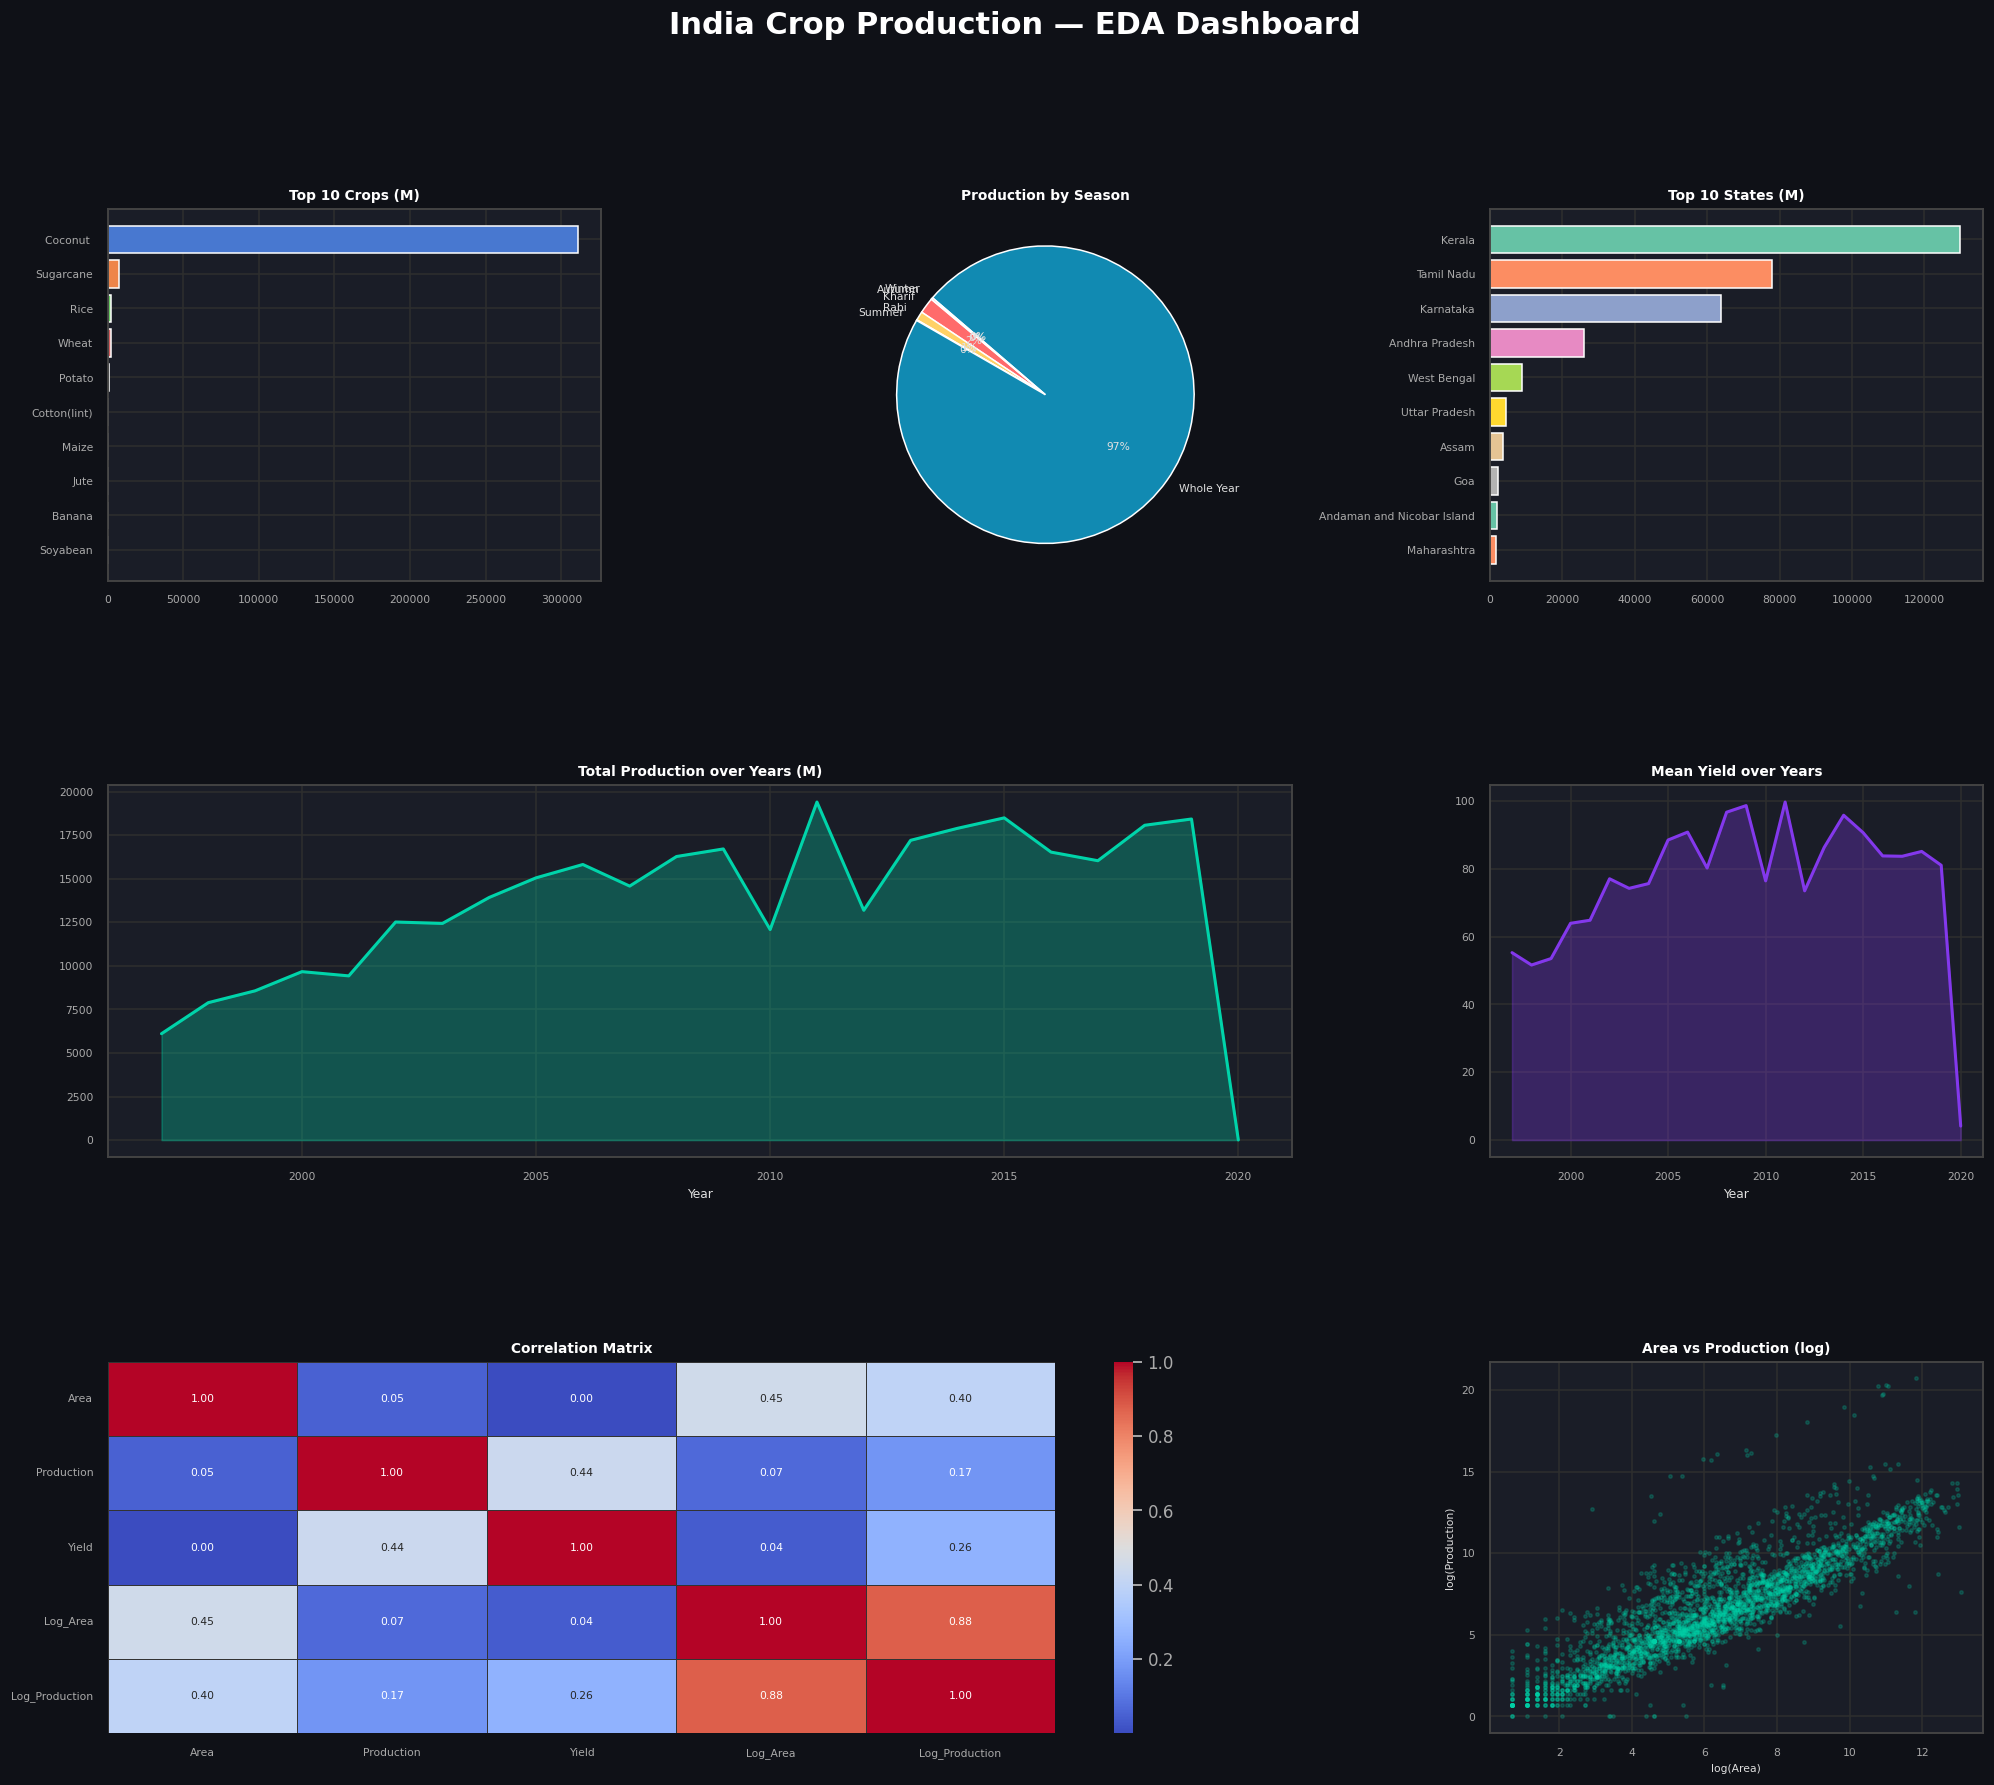

In [46]:
fig = plt.figure(figsize=(22, 18), facecolor='#0f1117')
fig.suptitle('India Crop Production — EDA Dashboard',
             fontsize=20, fontweight='bold', color='#ffffff', y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.4)

# Panel A — Top 10 crops
ax_a = fig.add_subplot(gs[0, 0])
t10_d = df_clean.groupby('Crop')['Production'].sum().nlargest(10)/1e6
ax_a.barh(t10_d.index, t10_d.values, color=sns.color_palette('muted', 10))
ax_a.set_title('Top 10 Crops (M)', fontsize=9, fontweight='bold')
ax_a.invert_yaxis(); ax_a.tick_params(labelsize=7)

# Panel B — Season share pie
ax_b = fig.add_subplot(gs[0, 1])
ss = df_clean.groupby('Season_clean')['Production'].sum()
ax_b.pie(ss, labels=ss.index, autopct='%1.0f%%',
         colors=PALETTE[:len(ss)], textprops={'fontsize': 7}, startangle=140)
ax_b.set_title('Production by Season', fontsize=9, fontweight='bold')

# Panel C — Top 10 states
ax_c = fig.add_subplot(gs[0, 2])
t10s_d = df_clean.groupby('State_Name')['Production'].sum().nlargest(10)/1e6
ax_c.barh(t10s_d.index, t10s_d.values, color=sns.color_palette('Set2', 10))
ax_c.set_title('Top 10 States (M)', fontsize=9, fontweight='bold')
ax_c.invert_yaxis(); ax_c.tick_params(labelsize=7)

# Panel D — Production over years
ax_d = fig.add_subplot(gs[1, :2])
ax_d.fill_between(yearly['Crop_Year'], yearly['Total_Production']/1e6,
                  alpha=0.3, color=ACCENT)
ax_d.plot(yearly['Crop_Year'], yearly['Total_Production']/1e6,
          color=ACCENT, linewidth=2)
ax_d.set_title('Total Production over Years (M)', fontsize=9, fontweight='bold')
ax_d.set_xlabel('Year', fontsize=8); ax_d.tick_params(labelsize=7)

# Panel E — Mean yield over years
ax_e = fig.add_subplot(gs[1, 2])
ax_e.fill_between(yearly['Crop_Year'], yearly['Mean_Yield'],
                  alpha=0.3, color='#8338ec')
ax_e.plot(yearly['Crop_Year'], yearly['Mean_Yield'],
          color='#8338ec', linewidth=2)
ax_e.set_title('Mean Yield over Years', fontsize=9, fontweight='bold')
ax_e.set_xlabel('Year', fontsize=8); ax_e.tick_params(labelsize=7)

# Panel F — Correlation heatmap
ax_f = fig.add_subplot(gs[2, :2])
small_corr = df_clean[['Area','Production','Yield',
                        'Log_Area','Log_Production']].corr()
sns.heatmap(small_corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax_f,
            linewidths=0.5, linecolor='#333', annot_kws={'size': 7})
ax_f.set_title('Correlation Matrix', fontsize=9, fontweight='bold')
ax_f.tick_params(labelsize=7)

# Panel G — Area vs Production scatter
ax_g = fig.add_subplot(gs[2, 2])
samp = (df_clean[['Log_Area','Log_Production']]
        .dropna().sample(3000, random_state=42))
ax_g.scatter(samp['Log_Area'], samp['Log_Production'],
             alpha=0.2, s=5, color=ACCENT)
ax_g.set_title('Area vs Production (log)', fontsize=9, fontweight='bold')
ax_g.set_xlabel('log(Area)', fontsize=7)
ax_g.set_ylabel('log(Production)', fontsize=7)
ax_g.tick_params(labelsize=7)

plt.show()


---
## 13. Machine Learning Feature Recommendations

### 🎯 Target Variables
| Variable | Type | Notes |
|---|---|---|
| `Production` | Regression | Use `log(Production)` as target — right-skewed |
| `Yield` | Regression | Productivity per unit area |

### 🔧 Feature Variables
| Feature | Encoding | Rationale |
|---|---|---|
| `Crop_Year` | Numeric (as-is) | Year trend |
| `Decade` | Label encode | Epoch grouping |
| `Season_clean` | One-hot (6 cats) | Season effect |
| `State_Name` | Target encode | High cardinality (37) |
| `District_Name` | Target encode | High cardinality (707) |
| `Crop` | Target/freq encode | High cardinality (55) |
| `Area` | Pass + log-transform | Direct predictor |

### 🤖 Suggested Models
1. **XGBoost / LightGBM** — Best for tabular data, robust to outliers
2. **Random Forest Regressor** — Handles skew, interpretable
3. **Linear Regression (log-space)** — Simple baseline
4. **LSTM** — Temporal trend prediction per State+Crop

### ✅ Pre-processing Checklist
- [ ] Impute `Production` NaN → median per `(State, Crop, Season)`
- [ ] Log-transform `Area` and `Production`
- [ ] One-hot encode `Season`
- [ ] Target-encode `Crop`, `State_Name`
- [ ] Cap outliers at 99th percentile or use robust scaler
